Econometrics Project

In [ ]:
# Libraries import
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from math import floor, sqrt
from scipy.stats import norm

from arch import arch_model


In [2]:
# Function to download data from Yahoo Finance and Download historical data for Copper and Shanghai Composite Index
def download_yahoo_data(ticker, start_date, end_date, interval='1d'):
    """
    Download historical data for a ticker from Yahoo Finance.
    
    Parameters:
    - ticker: stock symbol (e.g., 'AAPL' for Apple, 'GOOG' for Google)
    - start_date: start date in 'YYYY-MM-DD' format
    - end_date: end date in 'YYYY-MM-DD' format
    - interval: data frequency ('1d', '1wk', '1mo', '1y', etc.)
    
    Returns:
    - DataFrame with the historical data.
    """
    data = yf.download(ticker, start=start_date, end=end_date, interval=interval)
    return data

start_date_2015 = '2015-01-01'
mid_date_2019 = '2019-12-31'
mid_date_2020 = '2020-01-01'
end_date_2024 = '2024-12-31'
copper_id = 'HG=F'  # Yahoo Finance ticker for Copper Futures 
shanghai_composite_index_id = '000001.SS'  # Yahoo Finance ticker for Shanghai Composite Index
data_copper = download_yahoo_data(copper_id, start_date_2015, end_date_2024)
data_shanghai_composite_idx = download_yahoo_data(shanghai_composite_index_id, start_date_2015, end_date_2024)
print(data_copper.head())
print(data_shanghai_composite_idx.head())

# Download of data 2015-2019, 2020-2024
# Copper
data_copper_2015_2019 = data_copper.loc[start_date_2015:mid_date_2019]
data_copper_2020_2024 = data_copper.loc[mid_date_2020:end_date_2024]
# Shanghai Composite Index
data_shanghai_2015_2019 = data_shanghai_composite_idx.loc[start_date_2015:mid_date_2019]
data_shanghai_2020_2024 = data_shanghai_composite_idx.loc[mid_date_2020:end_date_2024]

/var/folders/mq/vjflf4v17wv_rvtlxmrx4rrc0000gn/T/ipykernel_12244/3201120245.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval=interval)
[*********************100%***********************]  1 of 1 completed
/var/folders/mq/vjflf4v17wv_rvtlxmrx4rrc0000gn/T/ipykernel_12244/3201120245.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date, interval=interval)
[*********************100%***********************]  1 of 1 completed

Price        Close    High     Low    Open Volume
Ticker        HG=F    HG=F    HG=F    HG=F   HG=F
Date                                             
2015-01-02  2.8385  2.8420  2.8365  2.8420    220
2015-01-05  2.7930  2.8295  2.7880  2.8295    326
2015-01-06  2.8040  2.8060  2.7915  2.7950    312
2015-01-07  2.7960  2.8090  2.7910  2.7920    463
2015-01-08  2.8070  2.8175  2.7865  2.7960    242
Price             Close         High          Low         Open    Volume
Ticker        000001.SS    000001.SS    000001.SS    000001.SS 000001.SS
Date                                                                    
2015-01-05  3350.519043  3369.281006  3253.883057  3258.626953    531400
2015-01-06  3351.446045  3394.224121  3303.184082  3330.799072    501700
2015-01-07  3373.954102  3374.895996  3312.210938  3326.648926    391900
2015-01-08  3293.456055  3381.565918  3285.094971  3371.957031    371100
2015-01-09  3285.412109  3404.833984  3267.509033  3276.965088    410200


In [3]:
# Function to convert DataFrame to NumPy array with dates and closing prices
def to_numpy_array(df):
    """
    Convert the DataFrame with 'Date' as index and 'Close' as the column of interest to a NumPy array.
    """
    # Extract dates and closing prices
    dates = df.index.strftime('%Y-%m-%d')  # Convert dates to string format
    closing_prices = df['Close'].values  # Get closing prices as a NumPy array
    
    # Combine the dates and closing prices into a 2D object array
    return np.column_stack((dates, closing_prices))

# Convert both datasets to NumPy arrays
copper_data_array = to_numpy_array(data_copper)
shanghai_data_array = to_numpy_array(data_shanghai_composite_idx)

# Show the resulting arrays
print("Copper Data (NumPy Array):")
print(copper_data_array)
print("Shanghai Composite Data (NumPy Array):")
print(shanghai_data_array)

# Transform data for 2015-2019 and 2020-2024 into NumPy arrays
copper_2015_2019_array = to_numpy_array(data_copper_2015_2019)
copper_2020_2024_array = to_numpy_array(data_copper_2020_2024)
shanghai_2015_2019_array = to_numpy_array(data_shanghai_2015_2019)
shanghai_2020_2024_array = to_numpy_array(data_shanghai_2020_2024)

Copper Data (NumPy Array):
[['2015-01-02' 2.8385000228881836]
 ['2015-01-05' 2.7929999828338623]
 ['2015-01-06' 2.803999900817871]
 ...
 ['2024-12-26' 4.072000026702881]
 ['2024-12-27' 4.0625]
 ['2024-12-30' 4.045499801635742]]
Shanghai Composite Data (NumPy Array):
[['2015-01-05' 3350.51904296875]
 ['2015-01-06' 3351.446044921875]
 ['2015-01-07' 3373.9541015625]
 ...
 ['2024-12-26' 3398.076904296875]
 ['2024-12-27' 3400.14208984375]
 ['2024-12-30' 3407.325927734375]]


In [4]:
# Function to compute returns, log returns, and squared log returns
def compute_returns(df):
    # Extract the Close prices and dates using the to_numpy_array function
    data = to_numpy_array(df)
    dates = data[:, 0]  # Dates are in the first column
    close = data[:, 1]  # Closing prices are in the second column

    # Ensure close is a numeric array (in case of any issues)
    close = np.array(close, dtype=float)

    # Calculate simple returns (% change) directly
    returns = close[1:] / close[:-1] - 1

    # Calculate log returns (log difference) without dropping NaNs
    log_returns = np.log(close[:-1] / close[1:])

    # Calculate squared log returns
    log_returns_squared = log_returns ** 2

    # Combine everything into a single numpy array with dates, returns, log returns, squared log returns
    result = np.column_stack((dates[1:], returns, log_returns, log_returns_squared))

    return result

# Compute returns, log returns, and squared log returns for both datasets
copper_metrics = compute_returns(data_copper)
shanghai_metrics = compute_returns(data_shanghai_composite_idx)

# Show the resulting NumPy arrays
print("Copper Metrics (Date, Returns, Log Returns, Squared Log Returns):")
print(copper_metrics[:5])  # Show first 5 rows for Copper

print("Shanghai Composite Metrics (Date, Returns, Log Returns, Squared Log Returns):")
print(shanghai_metrics[:5])  # Show first 5 rows for Shanghai Composite

# Compute metrics for 2015-2019 and 2020-2024 datasets
copper_2015_2019_metrics = compute_returns(data_copper_2015_2019)
copper_2020_2024_metrics = compute_returns(data_copper_2020_2024)
shanghai_2015_2019_metrics = compute_returns(data_shanghai_2015_2019)
shanghai_2020_2024_metrics = compute_returns(data_shanghai_2020_2024)


Copper Metrics (Date, Returns, Log Returns, Squared Log Returns):
[['2015-01-05' -0.016029607076777364 0.016159470875211406
  0.00026112849896680566]
 ['2015-01-06' 0.003938388131620396 -0.003930652983774201
  1.5450032878853028e-05]
 ['2015-01-07' -0.0028530304158856934 0.0028571080647803926
  8.16306649383316e-06]
 ['2015-01-08' 0.003934162363734339 -0.003926443784455239
  1.5416960792487182e-05]
 ['2015-01-09' -0.005878160543278388 0.005895504931094553
  3.475697839256019e-05]]
Shanghai Composite Metrics (Date, Returns, Log Returns, Squared Log Returns):
[['2015-01-06' 0.0002766741335407108 -0.00027663586631076765
  7.652740252950892e-08]
 ['2015-01-07' 0.0067159239143144145 -0.006693472562293853
  4.480257494218063e-05]
 ['2015-01-08' -0.0238586668495937 0.024147894497047368
  0.0005831208086405305]
 ['2015-01-09' -0.002442402503306851 0.002445390033793676
  5.9799324173774365e-06]
 ['2015-01-12' -0.017074324175703315 0.017221771231362478
  0.00029658940434538426]]


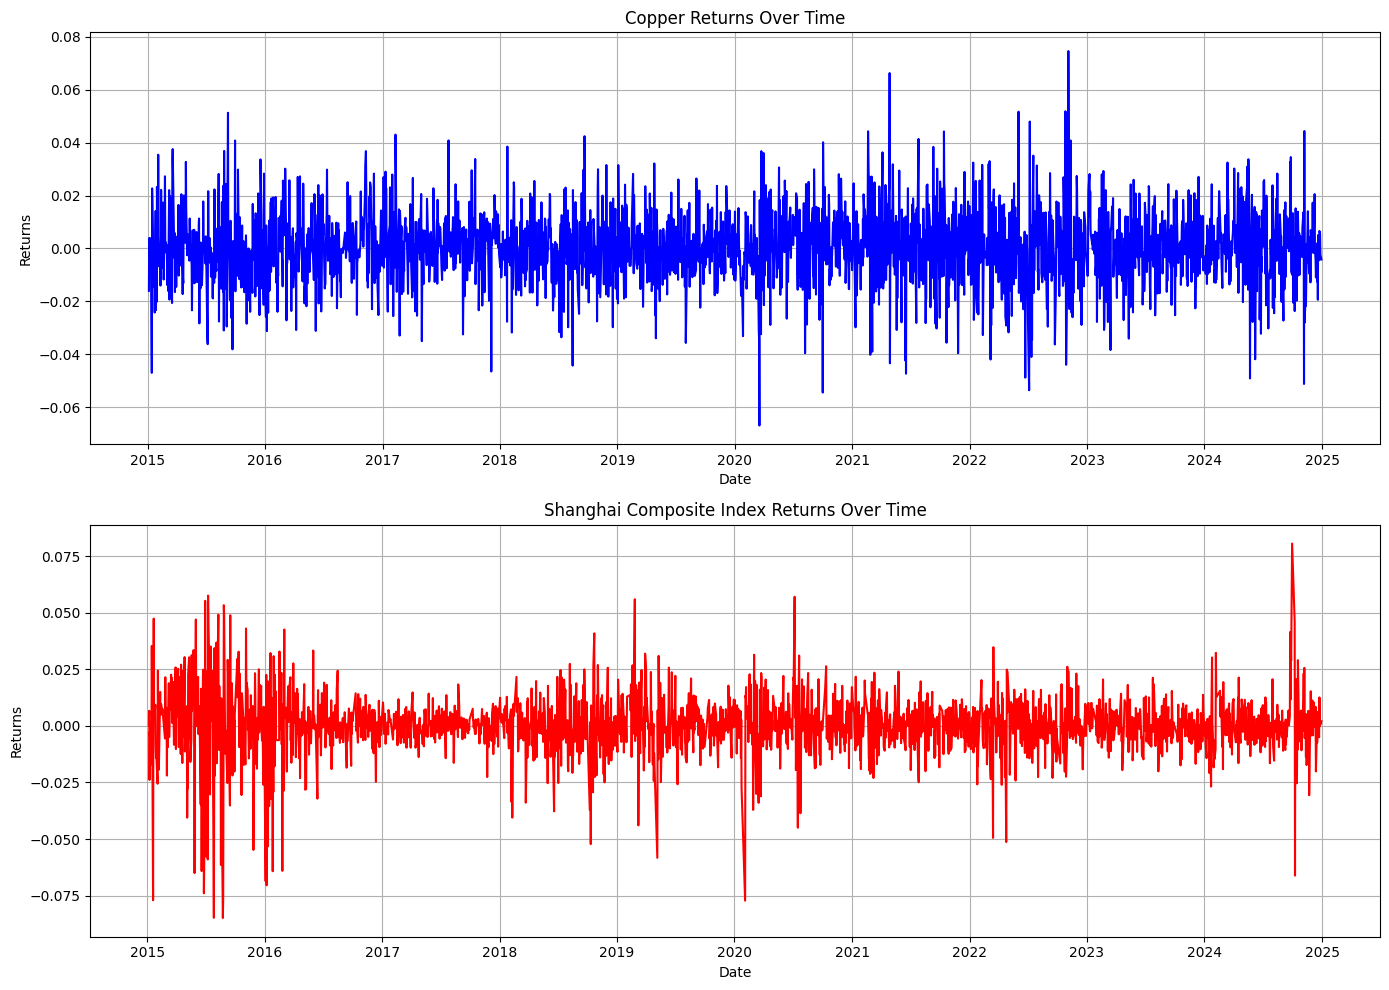

In [5]:
# Convert to datetime if not already
copper_dates = pd.to_datetime(copper_metrics[:, 0])
shanghai_dates = pd.to_datetime(shanghai_metrics[:, 0])

plt.figure(figsize=(14, 10))

# Copper Returns
plt.subplot(2, 1, 1)
plt.plot(copper_dates, copper_metrics[:, 1], color='blue')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.title('Copper Returns Over Time')
plt.grid(True)

# Shanghai Returns
plt.subplot(2, 1, 2)
plt.plot(shanghai_dates, shanghai_metrics[:, 1], color='red')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.title('Shanghai Composite Index Returns Over Time')
plt.grid(True)

plt.tight_layout()
plt.show()


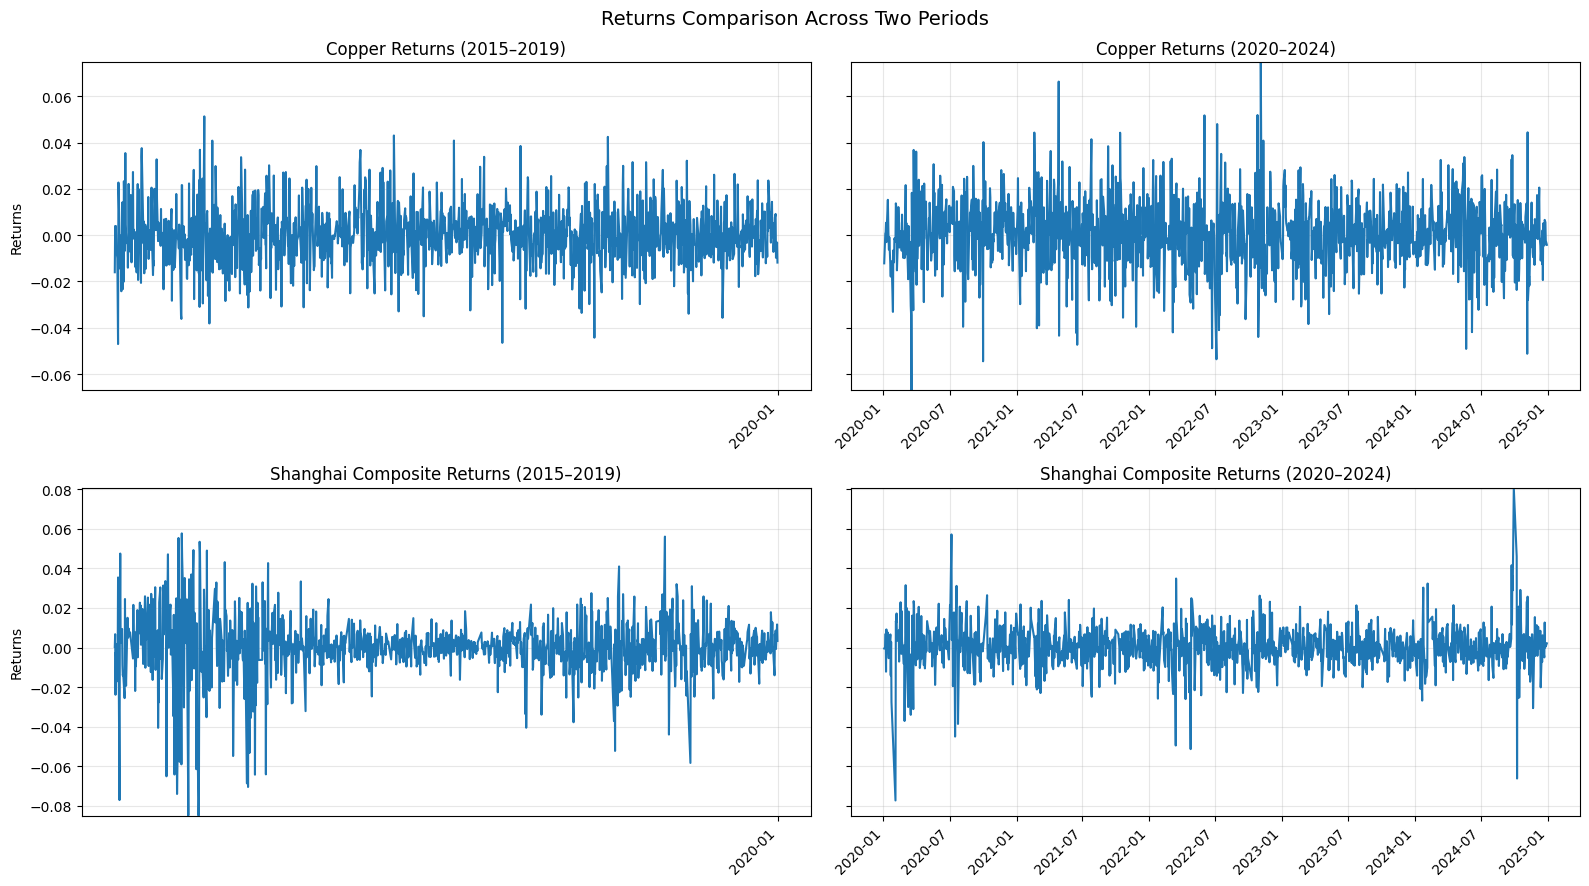

In [6]:
import numpy as np
import pandas as pd

def _to_datetime(col):
    """
    Convert a 1D array/Series of dates into pandas datetime64[ns],
    handling ISO strings, Unix (s/ms), YYYYMMDD ints, and Excel serials.
    """
    s = pd.Series(col)

    # Already datetime-like
    if np.issubdtype(s.dtype, np.datetime64):
        return pd.to_datetime(s)

    # Object or string → try generic parse
    if s.dtype == object or s.dtype == "string":
        parsed = pd.to_datetime(s, errors="coerce", utc=False)
        if parsed.notna().mean() > 0.95:
            return parsed

    # Numeric formats
    if np.issubdtype(s.dtype, np.number):
        vals = s.astype("float64")
        abs_vals = np.abs(vals.dropna())

        is_unix_s  = abs_vals.between(1e8, 1e10).mean() > 0.8
        is_unix_ms = abs_vals.between(1e11, 2e12).mean() > 0.8
        is_yyyymmdd = abs_vals.between(2e7, 3e8).mean() > 0.8
        is_excel = abs_vals.between(20000, 60000).mean() > 0.8

        if is_unix_ms:
            return pd.to_datetime(s, unit="ms", errors="coerce")
        if is_unix_s:
            return pd.to_datetime(s, unit="s", errors="coerce")
        if is_yyyymmdd:
            return pd.to_datetime(s.astype("Int64").astype(str), format="%Y%m%d", errors="coerce")
        if is_excel:
            return pd.to_datetime(s, origin="1899-12-30", unit="D", errors="coerce")

        parsed = pd.to_datetime(s, errors="coerce")
        if parsed.notna().any():
            return parsed

    return pd.to_datetime(s, errors="coerce")


# Convert date columns to datetime
cu15_dates = _to_datetime(copper_2015_2019_metrics[:, 0])
cu24_dates = _to_datetime(copper_2020_2024_metrics[:, 0])
sh15_dates = _to_datetime(shanghai_2015_2019_metrics[:, 0])
sh24_dates = _to_datetime(shanghai_2020_2024_metrics[:, 0])

# Extract returns
cu15_ret = copper_2015_2019_metrics[:, 1].astype(float)
cu24_ret = copper_2020_2024_metrics[:, 1].astype(float)
sh15_ret = shanghai_2015_2019_metrics[:, 1].astype(float)
sh24_ret = shanghai_2020_2024_metrics[:, 1].astype(float)

# Set y-limits per asset for fair comparison across its two periods
cu_min, cu_max = np.nanmin([cu15_ret.min(), cu24_ret.min()]), np.nanmax([cu15_ret.max(), cu24_ret.max()])
sh_min, sh_max = np.nanmin([sh15_ret.min(), sh24_ret.min()]), np.nanmax([sh15_ret.max(), sh24_ret.max()])

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey='row')
(ax_cu_15, ax_cu_24), (ax_sh_15, ax_sh_24) = axes

# Date formatter (monthly ticks, YYYY-MM)
fmt = mdates.DateFormatter('%Y-%m')
locator = mdates.AutoDateLocator(minticks=6, maxticks=12)

# --- Copper 2015-2019 ---
ax_cu_15.plot(cu15_dates, cu15_ret)
ax_cu_15.set_title('Copper Returns (2015–2019)')
ax_cu_15.set_ylabel('Returns')
ax_cu_15.grid(True, alpha=0.3)
ax_cu_15.xaxis.set_major_locator(locator)
ax_cu_15.xaxis.set_major_formatter(fmt)
ax_cu_15.set_ylim(cu_min, cu_max)

# --- Copper 2020-2024 ---
ax_cu_24.plot(cu24_dates, cu24_ret)
ax_cu_24.set_title('Copper Returns (2020–2024)')
ax_cu_24.grid(True, alpha=0.3)
ax_cu_24.xaxis.set_major_locator(locator)
ax_cu_24.xaxis.set_major_formatter(fmt)
ax_cu_24.set_ylim(cu_min, cu_max)

# --- Shanghai 2015-2019 ---
ax_sh_15.plot(sh15_dates, sh15_ret)
ax_sh_15.set_title('Shanghai Composite Returns (2015–2019)')
ax_sh_15.set_ylabel('Returns')
ax_sh_15.grid(True, alpha=0.3)
ax_sh_15.xaxis.set_major_locator(locator)
ax_sh_15.xaxis.set_major_formatter(fmt)
ax_sh_15.set_ylim(sh_min, sh_max)

# --- Shanghai 2020-2024 ---
ax_sh_24.plot(sh24_dates, sh24_ret)
ax_sh_24.set_title('Shanghai Composite Returns (2020–2024)')
ax_sh_24.grid(True, alpha=0.3)
ax_sh_24.xaxis.set_major_locator(locator)
ax_sh_24.xaxis.set_major_formatter(fmt)
ax_sh_24.set_ylim(sh_min, sh_max)

for ax in axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

fig.suptitle('Returns Comparison Across Two Periods', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


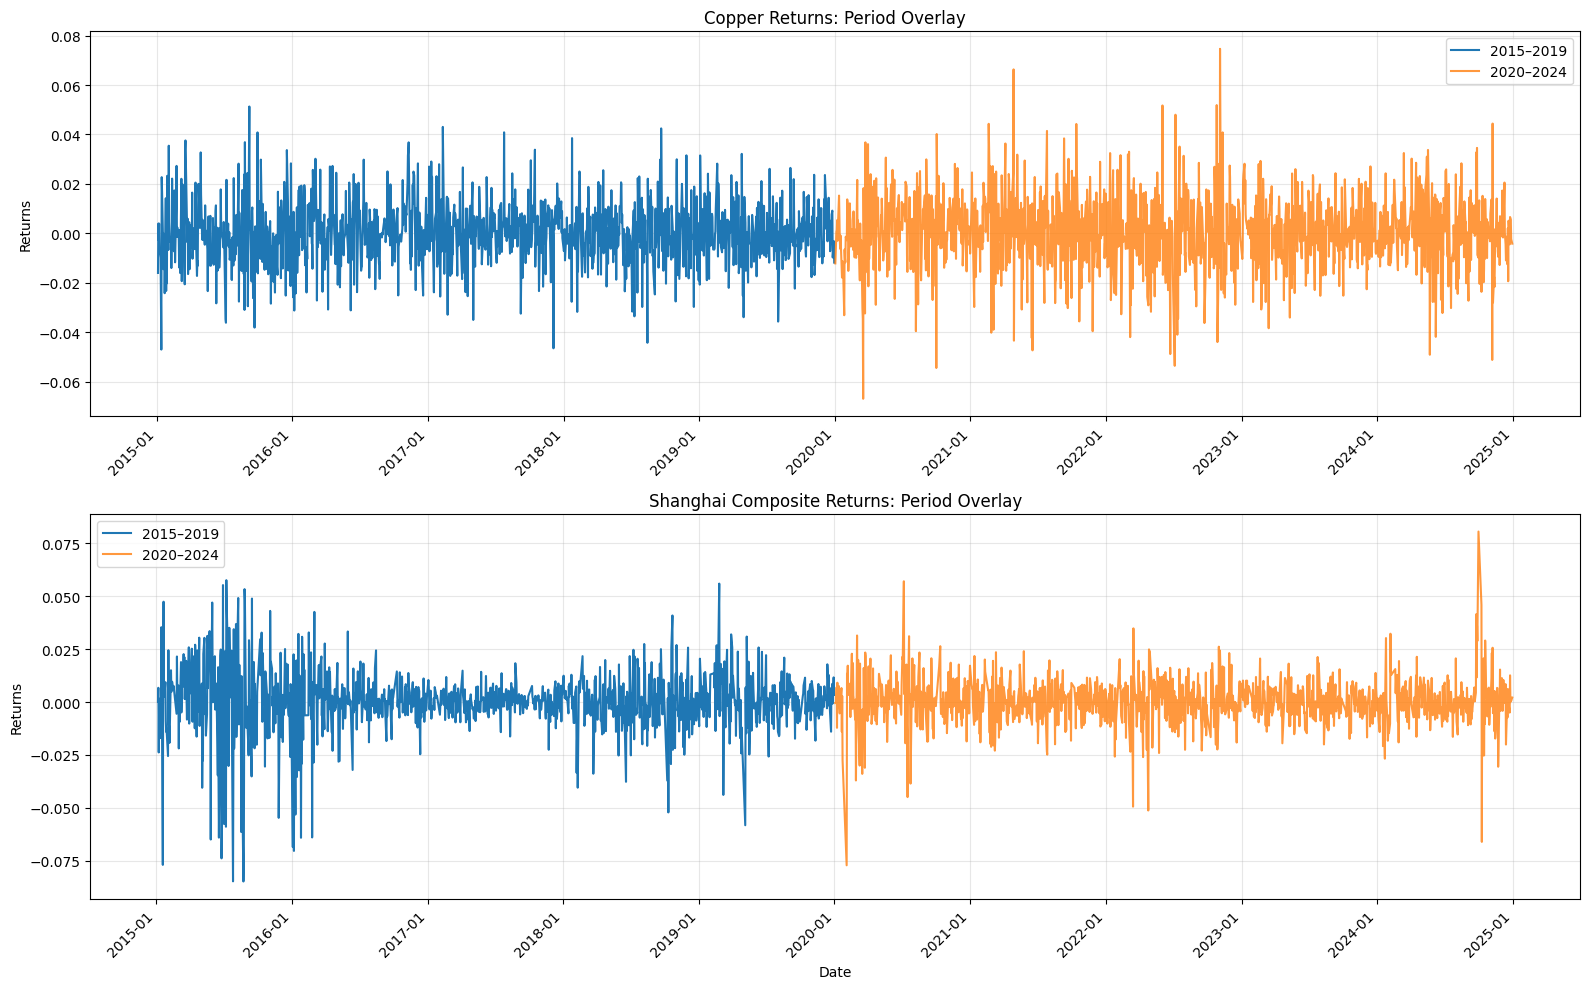

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

# Copper overlay
ax1.plot(cu15_dates, cu15_ret, label='2015–2019')
ax1.plot(cu24_dates, cu24_ret, label='2020–2024', alpha=0.8)
ax1.set_title('Copper Returns: Period Overlay')
ax1.set_ylabel('Returns')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.xaxis.set_major_locator(locator)
ax1.xaxis.set_major_formatter(fmt)

# Shanghai overlay
ax2.plot(sh15_dates, sh15_ret, label='2015–2019')
ax2.plot(sh24_dates, sh24_ret, label='2020–2024', alpha=0.8)
ax2.set_title('Shanghai Composite Returns: Period Overlay')
ax2.set_xlabel('Date')
ax2.set_ylabel('Returns')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.xaxis.set_major_locator(locator)
ax2.xaxis.set_major_formatter(fmt)

for ax in (ax1, ax2):
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

plt.tight_layout()
plt.show()


In [8]:
# Function to compute volatility (standard deviation of squared log returns)
def compute_volatility(metrics):
    squared_log_returns = metrics[:, 3]  # Extract squared log returns
    volatility = np.std(squared_log_returns)  # Compute the standard deviation of squared log returns
    return volatility

# Calculate volatilities for each period and dataset
copper_volatility_2015_2019 = compute_volatility(copper_2015_2019_metrics)
copper_volatility_2020_2024 = compute_volatility(copper_2020_2024_metrics)
shanghai_volatility_2015_2019 = compute_volatility(shanghai_2015_2019_metrics)
shanghai_volatility_2020_2024 = compute_volatility(shanghai_2020_2024_metrics)

# Print volatilities for each dataset and period
print("Copper Volatility 2015-2019:", copper_volatility_2015_2019)
print("Copper Volatility 2020-2024:", copper_volatility_2020_2024)
print("Shanghai Composite Volatility 2015-2019:", shanghai_volatility_2015_2019)
print("Shanghai Composite Volatility 2020-2024:", shanghai_volatility_2020_2024)


Copper Volatility 2015-2019: 0.00027907053117921956
Copper Volatility 2020-2024: 0.0004285201009693376
Shanghai Composite Volatility 2015-2019: 0.0006833771277157825
Shanghai Composite Volatility 2020-2024: 0.0003655575728982239


In [ ]:
# =========================
# HAC tests for volatility
# =========================

# ---------- 1) Utilities ----------

def compute_metrics_df(df):
    """
    Return a tidy DataFrame with Date, Return, LogReturn, SqLogReturn.
    NOTE: Fixes log-return direction to log(S_t / S_{t-1}).
    """
    out = pd.DataFrame(index=df.index.copy())
    close = df["Close"].astype(float)
    out["Return"] = close.pct_change()
    out["LogReturn"] = np.log(close / close.shift(1))
    out["SqLogReturn"] = out["LogReturn"]**2
    out = out.dropna()
    out = out.reset_index().rename(columns={"index": "Date"})
    return out[["Date", "Return", "LogReturn", "SqLogReturn"]]


def split_periods(df_metrics, start1="2015-01-01", end1="2019-12-31",
                  start2="2020-01-01", end2="2024-12-31"):
    """Split a metrics DataFrame into two periods (pre & post)."""
    m = df_metrics.copy()
    m["Date"] = pd.to_datetime(m["Date"])
    pre  = m[(m["Date"] >= pd.to_datetime(start1)) & (m["Date"] <= pd.to_datetime(end1))].copy()
    post = m[(m["Date"] >= pd.to_datetime(start2)) & (m["Date"] <= pd.to_datetime(end2))].copy()
    return pre.reset_index(drop=True), post.reset_index(drop=True)


def _autobandwidth_newey_west(n):
    """
    Automatic lag/truncation parameter q (Newey–West) for mean inference.
    Use a common rule-of-thumb: q = floor(4 * (n/100)^(2/9)) ∨ 1
    """
    q = int(np.floor(4.0 * (n / 100.0) ** (2.0 / 9.0)))
    return max(q, 1)


def long_run_variance_newey_west(x, q=None):
    """
    Newey–West long-run variance estimator for a (mean-zero) series x.
    Returns LRV = gamma(0) + 2 * sum_{h=1}^q w_h * gamma(h), with Bartlett weights.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.shape[0]
    if n < 3:
        return np.nan

    if q is None:
        q = _autobandwidth_newey_west(n)

    x_centered = x - x.mean()
    gamma0 = np.dot(x_centered, x_centered) / n
    lrv = gamma0

    for h in range(1, q + 1):
        # sample autocovariance at lag h
        cov_h = np.dot(x_centered[h:], x_centered[:-h]) / n
        weight = 1.0 - h / (q + 1.0)  # Bartlett kernel
        lrv += 2.0 * weight * cov_h

    return lrv


def hac_two_sample_mean_test(x, y, qx=None, qy=None, alternative="two-sided"):
    """
    HAC-robust two-sample test for equality of means of correlated series.
    x, y: arrays of observations (here, squared log-returns).
    Returns a dict with means, se, z-stat, pvalue, and chosen lags.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    n1, n2 = len(x), len(y)
    if n1 < 3 or n2 < 3:
        return {"stat": np.nan, "pvalue": np.nan, "se": np.nan, "n1": n1, "n2": n2}

    # Long-run variances of the centered processes (for mean inference)
    if qx is None: qx = _autobandwidth_newey_west(n1)
    if qy is None: qy = _autobandwidth_newey_west(n2)

    lrv_x = long_run_variance_newey_west(x, q=qx)
    lrv_y = long_run_variance_newey_west(y, q=qy)

    # HAC standard error for difference of means
    se = np.sqrt(lrv_x / n1 + lrv_y / n2)

    # Test statistic
    diff = x.mean() - y.mean()
    z = diff / se if se > 0 else np.nan

    # P-value
    if alternative == "two-sided":
        pval = 2.0 * (1.0 - norm.cdf(abs(z)))
    elif alternative == "larger":
        pval = 1.0 - norm.cdf(z)  # H1: mean_x > mean_y
    else:  # "smaller"
        pval = norm.cdf(z)        # H1: mean_x < mean_y

    return {
        "mean_x": x.mean(), "mean_y": y.mean(),
        "diff": diff, "se": se, "stat": z, "pvalue": pval,
        "lags_x": qx, "lags_y": qy, "n1": n1, "n2": n2
    }


def pretty_test(name, res):
    return {
        "Test": name,
        "n1": res["n1"], "n2": res["n2"],
        "mean_x": res["mean_x"], "mean_y": res["mean_y"],
        "diff": res["diff"], "HAC_SE": res["se"],
        "z_stat": res["stat"], "p_value": res["pvalue"],
        "lags_x": res["lags_x"], "lags_y": res["lags_y"]
    }


# ---------- 2) Build metrics from your existing data ----------

# Reuse your already-downloaded dataframes:
# - data_copper
# - data_shanghai_composite_idx

cu_metrics = compute_metrics_df(data_copper)
sh_metrics = compute_metrics_df(data_shanghai_composite_idx)

cu_pre, cu_post = split_periods(cu_metrics)
sh_pre, sh_post = split_periods(sh_metrics)

# Series to test: squared log-returns (volatility proxy)
cu_pre_sq  = cu_pre["SqLogReturn"].values
cu_post_sq = cu_post["SqLogReturn"].values
sh_pre_sq  = sh_pre["SqLogReturn"].values
sh_post_sq = sh_post["SqLogReturn"].values


# ---------- 3) Time-effect tests (2015–2019 vs 2020–2024) ----------

res_cu_time = hac_two_sample_mean_test(cu_post_sq, cu_pre_sq)  # post - pre
res_sh_time = hac_two_sample_mean_test(sh_post_sq, sh_pre_sq)  # post - pre

# ---------- 4) Cross-country tests within each period ----------

res_cross_pre  = hac_two_sample_mean_test(cu_pre_sq,  sh_pre_sq)   # copper - shanghai (2015–2019)
res_cross_post = hac_two_sample_mean_test(cu_post_sq, sh_post_sq)  # copper - shanghai (2020–2024)


# ---------- 5) Display results ----------
summary_rows = []
summary_rows.append(pretty_test("TIME Copper: mean(post) - mean(pre)", res_cu_time))
summary_rows.append(pretty_test("TIME Shanghai: mean(post) - mean(pre)", res_sh_time))
summary_rows.append(pretty_test("CROSS Pre (2015–2019): mean(Cu) - mean(Sh)", res_cross_pre))
summary_rows.append(pretty_test("CROSS Post (2020–2024): mean(Cu) - mean(Sh)", res_cross_post))
summary_df = pd.DataFrame(summary_rows)

# Order columns for readability
summary_df = summary_df[
    ["Test", "n1", "n2", "mean_x", "mean_y", "diff", "HAC_SE", "z_stat", "p_value", "lags_x", "lags_y"]
]
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
print("\n=== HAC/Newey–West robust tests on mean volatility (squared log-returns) ===")
print(summary_df)


# ---------- 6) (Optional) GARCH-based version ----------
# If you want to repeat the same tests on the *average conditional variance* from GARCH(1,1),
# uncomment and run the following. You'll need: pip install arch

def garch_conditional_variance_series(df_metrics):
    """
    Fit a GARCH(1,1) with zero mean and return the conditional variance series aligned to df_metrics.
    """
    r = df_metrics["LogReturn"].values
    am = arch_model(r * 100, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")  # scale in %
    res = am.fit(disp="off")
    
    # Handle both Series and ndarray return types
    sigma_pct = np.asarray(res.conditional_volatility)
    sigma = sigma_pct / 100.0
    cond_var = sigma**2
    return pd.Series(cond_var, index=df_metrics.index)

cu_metrics_g = cu_metrics.copy()
sh_metrics_g = sh_metrics.copy()
cu_metrics_g["CondVar"] = garch_conditional_variance_series(cu_metrics_g)
sh_metrics_g["CondVar"] = garch_conditional_variance_series(sh_metrics_g)

cu_pre_g, cu_post_g = split_periods(cu_metrics_g)
sh_pre_g, sh_post_g = split_periods(sh_metrics_g)

# Repeat HAC tests on the GARCH conditional variance series
res_cu_time_g = hac_two_sample_mean_test(cu_post_g["CondVar"].values, cu_pre_g["CondVar"].values)
res_sh_time_g = hac_two_sample_mean_test(sh_post_g["CondVar"].values, sh_pre_g["CondVar"].values)
res_cross_pre_g  = hac_two_sample_mean_test(cu_pre_g["CondVar"].values,  sh_pre_g["CondVar"].values)
res_cross_post_g = hac_two_sample_mean_test(cu_post_g["CondVar"].values, sh_post_g["CondVar"].values)

summary_rows_g = []
summary_rows_g.append(pretty_test("TIME Copper (GARCH var): post - pre", res_cu_time_g))
summary_rows_g.append(pretty_test("TIME Shanghai (GARCH var): post - pre", res_sh_time_g))
summary_rows_g.append(pretty_test("CROSS Pre (GARCH var): Cu - Sh", res_cross_pre_g))
summary_rows_g.append(pretty_test("CROSS Post (GARCH var): Cu - Sh", res_cross_post_g))
summary_df_g = pd.DataFrame(summary_rows_g)[summary_df.columns]
print("\n=== HAC/Newey–West robust tests on mean GARCH conditional variance ===")
print(summary_df_g)



=== HAC/Newey–West robust tests on mean volatility (squared log-returns) ===
                                          Test    n1    n2      mean_x  \
0          TIME Copper: mean(post) - mean(pre)  1258  1254  0.00023007   
1        TIME Shanghai: mean(post) - mean(pre)  1211  1216 0.000117567   
2   CROSS Pre (2015–2019): mean(Cu) - mean(Sh)  1254  1216 0.000158002   
3  CROSS Post (2020–2024): mean(Cu) - mean(Sh)  1258  1211  0.00023007   

       mean_y         diff      HAC_SE   z_stat     p_value  lags_x  lags_y  
0 0.000158002  7.20679e-05 1.74958e-05  4.11915 3.80279e-05       7       7  
1 0.000227898 -0.000110331 3.41995e-05 -3.22608  0.00125496       6       6  
2 0.000227898 -6.98956e-05 3.16993e-05 -2.20495   0.0274573       7       6  
3 0.000117567  0.000112503 2.16994e-05  5.18461  2.1647e-07       7       6  

=== HAC/Newey–West robust tests on mean GARCH conditional variance ===
                                    Test    n1    n2      mean_x      mean_y  \
0    TIME

In [ ]:
# ciao